# 项目四：KMeans 聚类（无监督学习入门）

**目标**：不告诉算法任何答案，让它自己把「长得像」的数据分成一伙一伙的。

## 无监督 vs 有监督，差在哪？

回想一下前面三个项目，训练时都写了这行：

```python
model.fit(X_train, y_train)   # 带着答案 y 学
```

那个 `y_train` 就是「答案」（这张图是数字 3、这个人遇难了）。**有监督** = 学习时每个数据都带着答案。

而**无监督学习，没有答案**。给你一堆数据，没有标签，让算法自己找规律：哪些数据「长得很像」，自动分成一伙。

```python
model.fit(X)   # 只有数据 X，没有答案 y！
```

> 从下往上跑，`Shift + Enter` 逐个执行。

## KMeans 的核心思想（先理解再写代码）

KMeans 想把数据分成 K 伙，做法是**反复做两件事**，直到稳定：

1. **分派**：每个点，归给「离它最近的中心点」那一伙
2. **更新**：重新算每一伙的中心点（这一伙所有点的平均值）

就像往地上撒一堆豆子，先随便放 K 个标记，然后：

- 每颗豆子跑到最近的标记 → 形成 K 堆
- 每个标记挪到它那堆豆子的正中间
- 重复……直到标记不再动

**关键难点：K 得你自己定。** 下面你会学到怎么选 K。

c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 22242 (\N{CJK UNIFIED IDEOGRAPH-56E2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 39068 (\N{CJK UNIFIED IDEOGRAPH-989C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: G

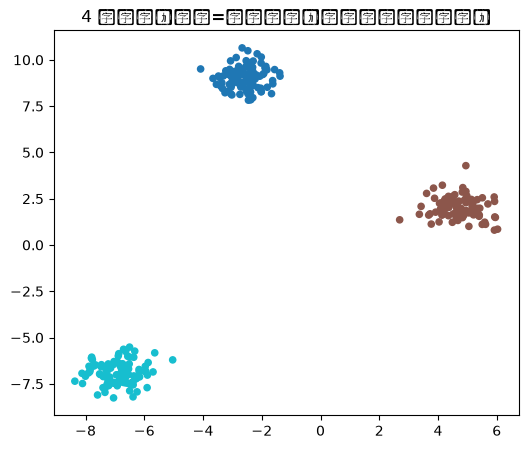

In [6]:
# 第 1 步：生成 4 团人造数据（用来看清楚 KMeans 在干什么）
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 生成 300 个点，分布在 4 个中心附近
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=42)

# 画出来看。颜色 y_true 是「真实答案」，但我们做无监督时假装不知道它
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap="tab10", s=20)
plt.title("4 团数据（颜色=真实答案，但我们假装不知道）")
plt.show()

c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 31572 (\N{CJK UNIFIED IDEOGRAPH-7B54}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 26696 (\N{CJK UNIFIED IDEOGRAPH-6848}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: G

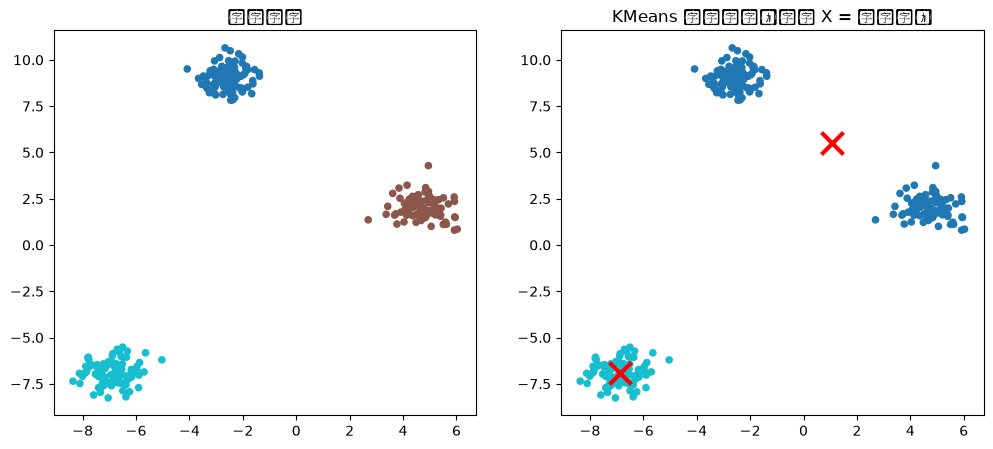

KMeans 找到了 4 个中心点，位置在：
[[ 1.06029745  5.51374038]
 [-6.88217395 -6.94243433]]


In [ ]:
# 第 2 步：KMeans 聚类，让它自己找团
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)          # 注意！只传 X，没有 y —— 这就是「无监督」

y_pred = kmeans.labels_   # 算法自己分出的类别

# 对比：左边是真实答案，右边是 KMeans 自己分的结果
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap="tab10", s=20)
axes[0].set_title("真实答案")
axes[1].scatter(X[:, 0], X[:, 1], c=y_pred, cmap="tab10", s=20)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                marker="x", s=250, color="red", linewidths=3)
axes[1].set_title("KMeans 自己分的（红色 X = 中心点）")
plt.show()

print("KMeans 找到了 4 个中心点，位置在：")
print(kmeans.cluster_centers_)

## 怎么选 K？—— 肘部法则

上面我们「知道」数据是 4 团，所以直接设 K=4。但真实数据你不知道有几团，怎么办？

**肘部法则**：从 K=1 一直试到 K=10，每次都算一个「簇内误差」（inertia，每个点到它中心点的距离平方和，越小说明分得越紧凑）。

K 越大，误差肯定越小（分得越细越紧凑），但会「得不偿失」。曲线会在某个 K 处出现一个**拐点（肘部）**——拐点之前误差下降很快，之后变慢。那个拐点就是最优 K。

c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 31751 (\N{CJK UNIFIED IDEOGRAPH-7C07}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 20869 (\N{CJK UNIFIED IDEOGRAPH-5185}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: G

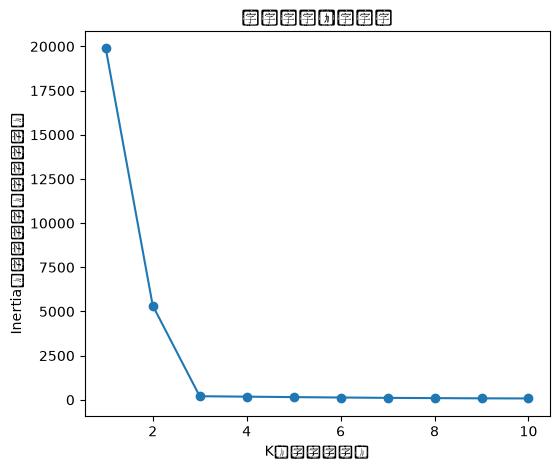

看曲线的拐点在哪？那个 K 就是最佳选择。


In [15]:
# 第 3 步：肘部法则，找最优 K
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 5))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("K（分成几伙）")
plt.ylabel("Inertia（簇内误差，越小越好）")
plt.title("肘部法则：找拐点")
plt.show()

print("看曲线的拐点在哪？那个 K 就是最佳选择。")

c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 24275 (\N{CJK UNIFIED IDEOGRAPH-5ED3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: G

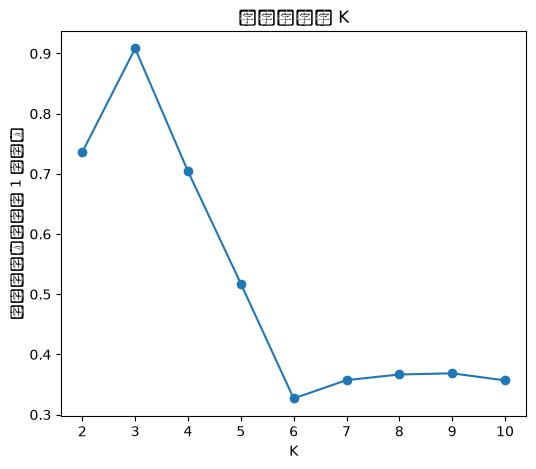

轮廓系数最高的 K = 3


In [14]:
# 第 4 步：另一个选 K 的指标 —— 轮廓系数
# 轮廓系数衡量「团分得好不好」，越接近 1 越好
scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    scores.append(silhouette_score(X, labels))

plt.figure(figsize=(6, 5))
plt.plot(range(2, 11), scores, marker="o")
plt.xlabel("K")
plt.ylabel("轮廓系数（越接近 1 越好）")
plt.title("轮廓系数选 K")
plt.show()

print("轮廓系数最高的 K =", np.argmax(scores) + 2)

## 实战：用你熟悉的鸢尾花做无监督聚类

前面监督学习时，我们用鸢尾花的**标签**训练分类器。现在反过来：**假装没有标签**，让 KMeans 自己把 150 朵花分成 3 类，再和真实标签对比，看它「蒙」得准不准。

> 注意一个现象：聚类出来的**类别编号**可能和真实编号对不上（比如真实第 0 类可能被聚成第 2 类）。但聚出来的**团**的形状应该大体重合。这就是无监督的特点：编号是任意的，形状才是本质。

c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: G

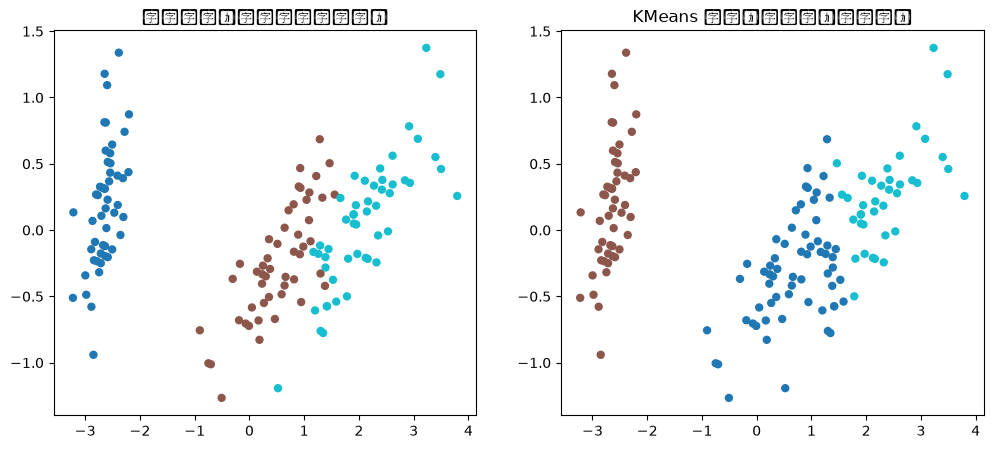

In [5]:
# 第 5 步：鸢尾花无监督聚类
iris = load_iris()
X_iris = iris.data
y_iris = iris.target   # 真实标签（只用来事后验证，训练时不用！）

kmeans_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred_iris = kmeans_iris.fit_predict(X_iris)   # 还是只有 X，没有 y

# 用 PCA 降到 2 维可视化
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_iris)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_iris, cmap="tab10", s=25)
axes[0].set_title("真实标签（监督学习有答案）")
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_pred_iris, cmap="tab10", s=25)
axes[1].set_title("KMeans 聚类（无监督，没答案）")
plt.show()

## 自己动手改（练习）

1. **肘部法则**那张图的拐点，大概在 K=几？是不是正好等于我们生成数据时设的 4 团？
2. 把 `make_blobs` 的 `centers=4` 改成 `3` 或 `5`，重新跑，肘部法则还能找到正确的 K 吗？
3. 鸢尾花那两张图：**团的形状一样吗？颜色编号对得上吗？** 如果编号对不上，说明什么？（提示：想无监督的类别编号是怎么定的）
4. 把鸢尾花聚类的 `n_clusters=3` 改成 `2` 或 `4`，结果怎么变？——想想：如果真实数据根本不是 3 类，你强行聚成 3 类会发生什么？

**核心体会**：无监督学习最大的特点就是「没有标准答案」。你永远无法确定「分对了没有」，只能靠肘部法则、轮廓系数这些间接指标，加上人的判断，去挑一个合理的 K。